# 05 — Concentration Similarity Index (Byrne 2024)

Builds the network daily matrix from cleaned, humidity-corrected data, computes
the pairwise CSI, and produces the fault-candidate ranking, heatmap, map and
distance plot.

The CSI is applied to daily rather than hourly means, for the coverage reasons
established in NB04. Sensors with fewer than `MIN_VALID_DAYS` valid days are
dropped before the index is computed, since a similarity ranking built on a
handful of days is a statement about coverage rather than about the
instruments.

One property of the index governs how its output is read here. Byrne et al.
(2024, Sect. 2.1.1) harmonise every sensor onto a common reference by linear
regression *before* computing the CSI, using co-location data, and describe
that step as a prerequisite. No Leeds sensor has been co-located, so nothing
here separates a sensor that disagrees because of its calibration from one that
disagrees because of the air it sits in. That is useful for finding fault
candidates and insufficient for diagnosing them, which is what NB08 is for.

In [1]:
import re
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.config import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
import matplotlib.colors as mcolors
from src.cleaning import apply_humidity_correction
from src.csi import csi_matrix, sensor_ranking
from src.baseline import haversine_km


def short_code(name: str) -> str:
    """'SL_017_-_Boston_Spa...' -> 'SL017'; 'SL001_Sunnyview...' -> 'SL001'."""
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

### Clean rows → Barkjohn correction → daily means → network matrix

Rows without RH are dropped before the daily mean (they can't be corrected), and the `MIN_READINGS_PER_DAY` completeness check runs on the post-drop count. For sensors with patchy RH (SL006 at 55% is the extreme case) the daily means therefore come from a subset of each day — flagged in the printout so it isn't silent.

In [2]:
daily_series = {}
rows = []

for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue

    n_before = len(clean)
    clean[DATE_COL]    = pd.to_datetime(clean[DATE_COL])
    clean["pm25_corr"] = apply_humidity_correction(clean)
    clean = clean.dropna(subset=["pm25_corr"])          # rows without RH
    rh_loss = 1 - len(clean) / n_before
    if rh_loss > 0.05:
        print(f"  ! {name}: {rh_loss:.0%} of clean rows lack RH — "
              f"daily means use a subset of each day")

    agg   = clean.set_index(DATE_COL)["pm25_corr"].resample("D").agg(["mean", "count"])
    valid = agg.loc[agg["count"] >= MIN_READINGS_PER_DAY, "mean"]
    if len(valid) < MIN_VALID_DAYS:
        print(f"  ! {name}: only {len(valid)} valid days "
              f"(< {MIN_VALID_DAYS}), excluded from the CSI")
        continue

    daily_series[name] = valid
    rows.append({
        "sensor":     name,
        "valid_days": len(valid),
        "first_day":  valid.index.min().date(),
        "last_day":   valid.index.max().date(),
        "mean_daily": round(valid.mean(), 2),
        "max_daily":  round(valid.max(), 2),
    })

daily_matrix = pd.DataFrame(daily_series).sort_index()
daily_matrix.to_parquet(DAILY_MATRIX)

summary = pd.DataFrame(rows).sort_values("valid_days", ascending=False)
summary.to_csv(Tables / "daily_matrix_summary.csv", index=False)

print(f"\nmatrix shape: {daily_matrix.shape[0]} days x {daily_matrix.shape[1]} sensors")
print(f"date range:   {daily_matrix.index.min().date()} -> {daily_matrix.index.max().date()}")
print(summary.to_string(index=False))

  ! SL001_Sunnyview_Terrace: 11% of clean rows lack RH — daily means use a subset of each day
  ! SL006: 46% of clean rows lack RH — daily means use a subset of each day
  ! SL016_Scholes_Main_Street: 10% of clean rows lack RH — daily means use a subset of each day
  ! SL022_Church_Lane_Horsforth: 7% of clean rows lack RH — daily means use a subset of each day
  ! SL030: only 14 valid days (< 100), excluded from the CSI
  ! SL031: only 56 valid days (< 100), excluded from the CSI
  ! SL042: 22% of clean rows lack RH — daily means use a subset of each day
  ! SL057: only 41 valid days (< 100), excluded from the CSI
  ! SL060: only 66 valid days (< 100), excluded from the CSI

matrix shape: 1616 days x 43 sensors
date range:   2022-03-09 -> 2026-08-10
                          sensor  valid_days  first_day   last_day  mean_daily  max_daily
      SL024_Wetherby_Town_Centre        1395 2022-03-22 2026-08-10        3.53      34.93
         SL007_Ninelands_Primary        1332 2022-07-13 2026

### How often does the humidity correction hit its floor?

The Barkjohn correction subtracts a humidity term, so it returns a negative
value whenever `0.524·PA + 5.75 < 0.0862·RH`. At a Leeds-typical 2.4 µg/m³ that
happens above about 81% RH, and `apply_humidity_correction` floors the result at
zero. Everything downstream depends on how often that floor is reached: the CSI
treats two zeros as agreeing only when both are exactly zero, and a floor makes
low-reading sensors artificially identical to one another.

The second check is the cf_atm question. Barkjohn et al. fitted the correction
to cf_1, while this archive exports cf_atm. The two columns agree 1:1 below
about 25 µg/m³ as reported by the sensor and diverge above it, so the count
below says what share of the data the substitution actually affects.

In [3]:
clip_rows = []
for path in sorted(CLEANED.glob("*.parquet")):
    df = pd.read_parquet(path, columns=[PM_A, PM_B, RH_COL, "is_clean"])
    clean = df[df["is_clean"]]
    if clean.empty:
        continue
    pa = (clean[PM_A] + clean[PM_B]) / 2
    corr = apply_humidity_correction(clean)
    have_rh = corr.notna()
    if not have_rh.any():
        continue
    clip_rows.append({
        "sensor": short_code(path.stem),
        "n_clean_with_rh": int(have_rh.sum()),
        "pct_at_zero":     round(100 * (corr[have_rh] == 0).mean(), 1),
        "pct_above_cf_lim": round(100 * (pa[have_rh] > CF_EQUIV_LIMIT).mean(), 2),
        "median_rh":       round(clean.loc[have_rh, RH_COL].median(), 1),
    })

clip = pd.DataFrame(clip_rows).sort_values("pct_at_zero", ascending=False)
clip.to_csv(Tables / "correction_clipping.csv", index=False)

print(f"readings floored at zero by the correction: "
      f"network median {clip['pct_at_zero'].median():.1f}%, "
      f"worst sensor {clip['pct_at_zero'].max():.1f}% ({clip.iloc[0]['sensor']})")
print(f"readings above the cf_atm/cf_1 equivalence limit of {CF_EQUIV_LIMIT} µg/m³: "
      f"network median {clip['pct_above_cf_lim'].median():.2f}%")
print()
print(clip.head(8).to_string(index=False))

readings floored at zero by the correction: network median 10.8%, worst sensor 61.4% (SL050)
readings above the cf_atm/cf_1 equivalence limit of 25 µg/m³: network median 6.06%

sensor  n_clean_with_rh  pct_at_zero  pct_above_cf_lim  median_rh
 SL050           628344         61.4              5.46      100.0
 SL006           428563         41.0              2.65       70.0
 SL022           407621         40.1              8.50       73.0
 SL018           312293         32.0              0.86       65.0
 SL028            77132         29.2              2.63       67.0
 SL024           897572         24.1              6.90       64.0
 SL008           514481         22.8              0.37       62.0
 SL023           210300         19.1              2.45       63.0


If the floored share is small, the correction is behaving as a
standardising transform and the CSI below is measuring what it is meant to. If
it is large, the low end of every series has been compressed onto a common
value and the similarity scores of the cleanest sensors are partly an artefact
of that compression — which would have to be carried into the interpretation of
the ranking, and into NB08.

### Network density sanity check

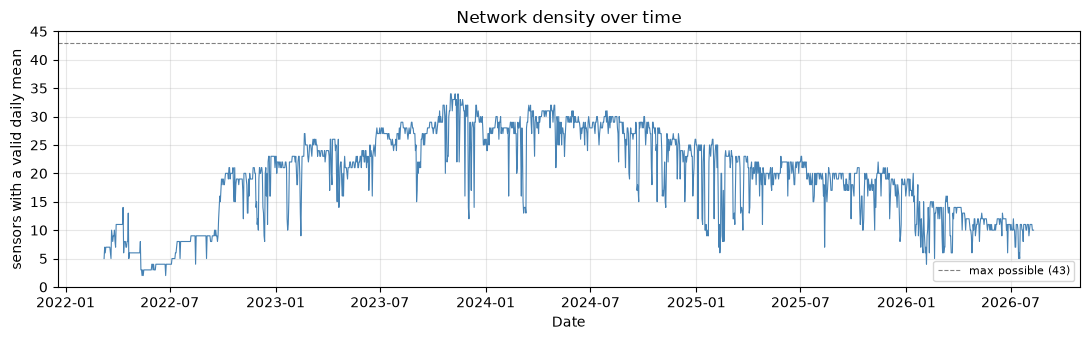

median sensors/day: 20  (of 43 maximum)
days with >= 10 sensors: 1384 of 1616


In [4]:
sensors_per_day = daily_matrix.notna().sum(axis=1)
n_max = daily_matrix.shape[1]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sensors_per_day.index, sensors_per_day.values, lw=0.8, color="steelblue")
ax.axhline(n_max, color="grey", ls="--", lw=0.8, label=f"max possible ({n_max})")
ax.set_ylabel("sensors with a valid daily mean")
ax.set_xlabel("Date")
ax.set_title("Network density over time")
ax.legend(fontsize=8)
ax.set_ylim(0, n_max + 2)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(Figures / "05_network_daily_density.png", dpi=150)
plt.show()

print(f"median sensors/day: {sensors_per_day.median():.0f}  (of {n_max} maximum)")
print(f"days with >= 10 sensors: {(sensors_per_day >= 10).sum()} of {len(sensors_per_day)}")

### Compute the CSI matrix

Pairs with fewer than `CSI_MIN_COMMON_DAYS` overlapping days stay NaN (white cells in the heatmap) — too little shared record to judge similarity.

In [5]:
csi, ncommon = csi_matrix(daily_matrix)

csi.round(3).to_csv(Tables / "csi_matrix.csv")
ncommon.to_csv(Tables / "csi_common_days.csv")

vals = csi.where(~np.eye(len(csi), dtype=bool)).stack()
print(f"pairs computed: {vals.notna().sum() // 2}  "
      f"(of {len(csi)*(len(csi)-1)//2} possible)")
print(f"network mean CSI: {vals.mean():.3f}   "
      f"min: {vals.min():.3f}   max: {vals.max():.3f}")

pairs computed: 847  (of 903 possible)
network mean CSI: 0.714   min: 0.000   max: 0.986


### Figure 2 — Pairwise CSI heatmap

Sensors are sorted by mean off-diagonal CSI so that fault candidates cluster in the top-left corner. The colour scale runs from 0.4 (red) to 1.0 (green), zooming into the realistic range. White cells have fewer than `MIN_COMMON_DAYS` overlapping days.

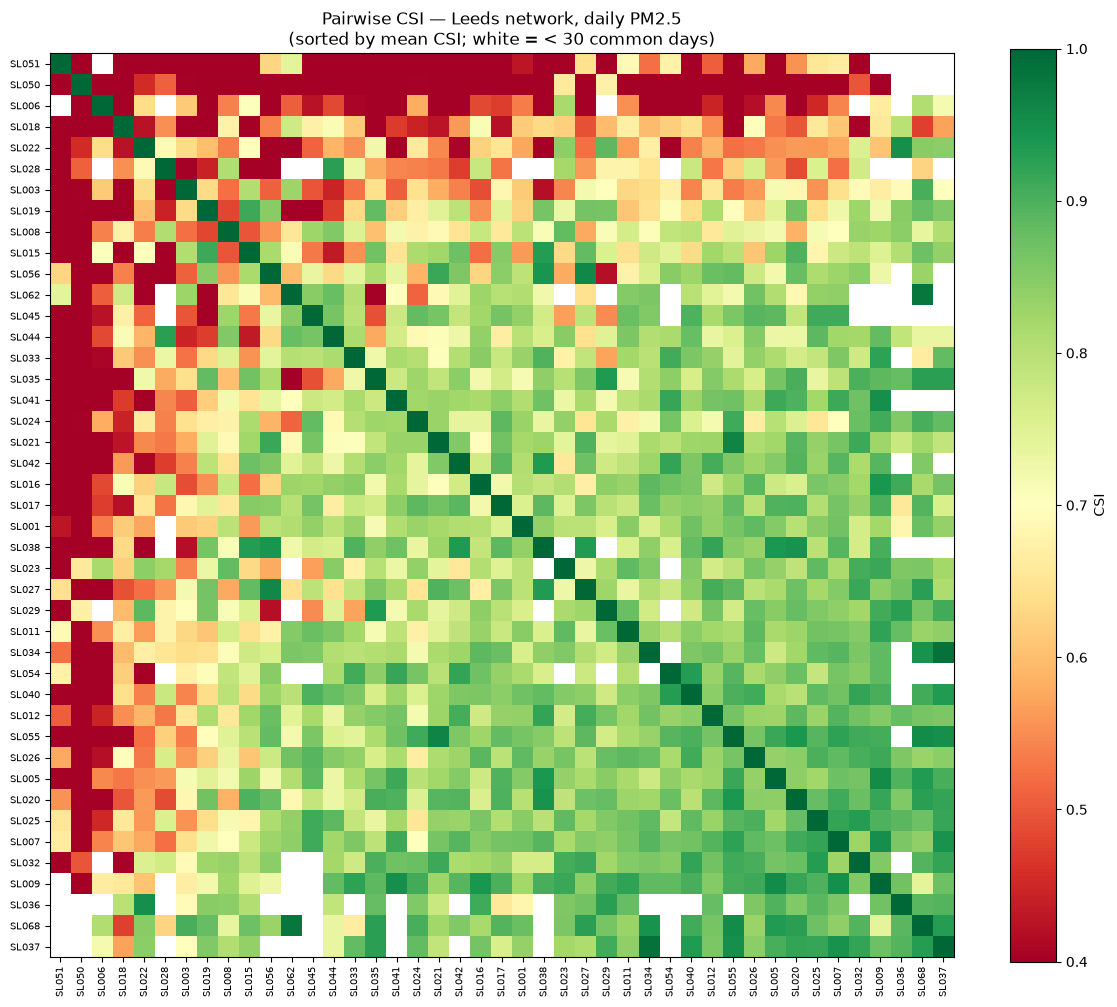

In [6]:
# Sort sensors by mean off-diagonal CSI (worst at top-left)
mean_csi_per_sensor = csi.where(~np.eye(len(csi), dtype=bool)).mean(axis=1)
order = mean_csi_per_sensor.sort_values().index
csi_sorted   = csi.loc[order, order]
short_sorted = [short_code(c) for c in order]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(csi_sorted.values, vmin=0.4, vmax=1.0, cmap="RdYlGn")
ax.set_xticks(range(len(short_sorted)))
ax.set_xticklabels(short_sorted, rotation=90, fontsize=7)
ax.set_yticks(range(len(short_sorted)))
ax.set_yticklabels(short_sorted, fontsize=7)
fig.colorbar(im, ax=ax, label="CSI")
ax.set_title(f"Pairwise CSI — Leeds network, daily PM2.5\n"
             f"(sorted by mean CSI; white = < {MIN_COMMON_DAYS} common days)")
fig.tight_layout()
fig.savefig(Figures / "05_csi_heatmap.png", dpi=150)
plt.show()

### Mean CSI per sensor, with pair counts

Low mean CSI on **many** pairs with **long** overlap is evidence; low mean CSI on a handful of short overlaps is not. The A/B disagreement rates from notebook 04 are merged in so both fault detectors sit in one table — the basis of the two-axis triage.

In [7]:
rank = sensor_ranking(csi, ncommon)
rank.index = [short_code(s) for s in rank.index]
rank.index.name = "sensor"

# merge the A/B fault-candidate table from notebook 04, if present
ab_path = Tables / "cleaning_summary.csv"
if ab_path.exists():
    ab = pd.read_csv(ab_path)
    ab["sensor"] = ab["sensor"].map(short_code)
    rank = rank.join(ab.set_index("sensor")["pct_ab_flag"], how="left")

rank.to_csv(Tables / "csi_sensor_ranking.csv")

print("Least similar to the network (potential faults or unusual sites):")
print(rank.head(10).to_string())
print("\nMost similar:")
print(rank.tail(5).to_string())

Least similar to the network (potential faults or unusual sites):
        mean_csi  n_pairs  median_overlap_days  pct_ab_flag
sensor                                                     
SL051      0.316       37                 85.0         12.2
SL050      0.320       39                478.0         15.5
SL006      0.460       37                360.0         24.6
SL018      0.536       42                383.0         50.6
SL022      0.582       42                411.0         13.4
SL028      0.583       33                 94.0         18.3
SL003      0.587       42                371.0         31.9
SL019      0.658       42                604.0         13.3
SL008      0.682       42                484.0         33.3
SL015      0.694       42                304.0         15.1

Most similar:
        mean_csi  n_pairs  median_overlap_days  pct_ab_flag
sensor                                                     
SL032      0.806       38                208.0         30.9
SL009      0.836   

### Figure 3 — Geographic CSI map

A fault signature appears as a dark (low-CSI) point isolated among green neighbours. A dark patch of geographically adjacent sensors would instead suggest a real local air-quality signal rather than an instrument fault. The colour scale matches the heatmap (0.4 red → 1.0 green).

c:\Users\user\Desktop\University\Dissertation\Dissertation Sensing Leeds Air Quality\.venv\Lib\site-packages\joblib\memory.py:607: UserWarning: Persisting input arguments took 0.98s to run.If this happens often in your code, it can cause performance problems (results will be correct in all cases). The reason for this is probably some large input arguments for a wrapped function.
  return self._cached_call(args, kwargs, shelving=False)[0]


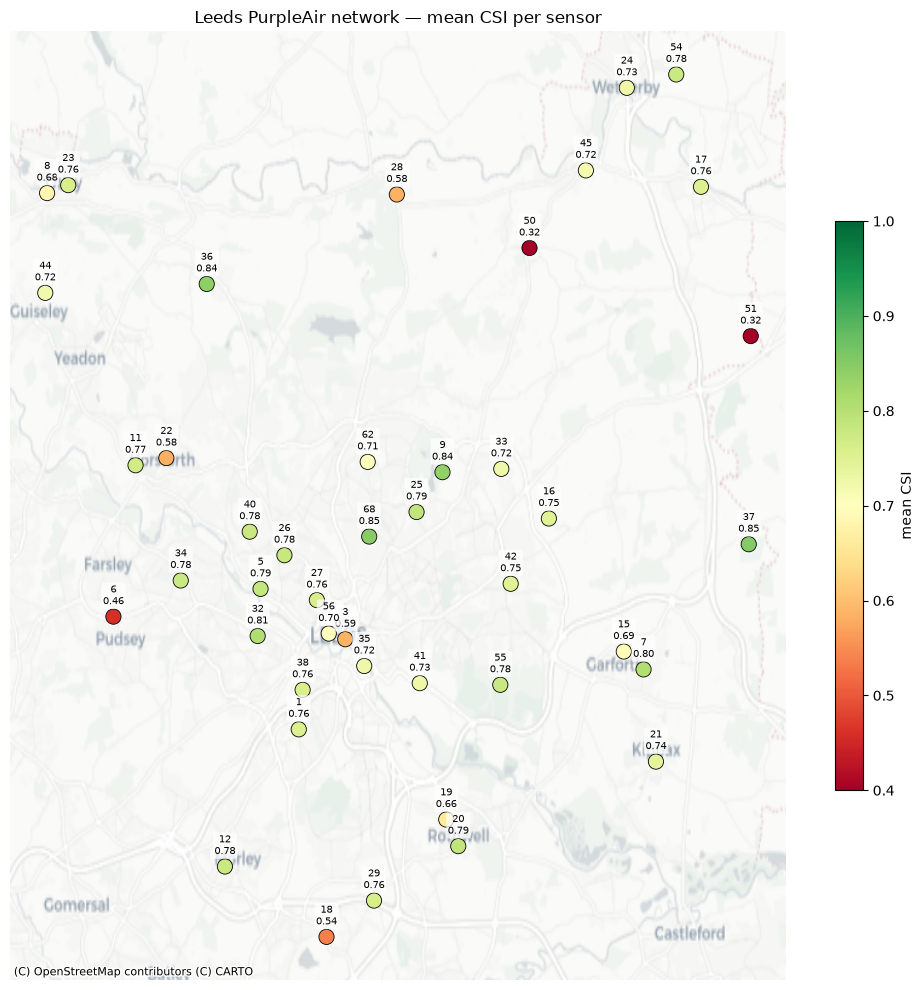

In [8]:
sensors = pd.read_csv(Tables / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
coords = sensors.set_index("code")[["lat", "lon"]]

m = coords.join(rank["mean_csi"], how="inner").dropna(subset=["mean_csi"])
missing = sorted(set(rank.index) - set(m.index))
if missing:
    print(f"no coordinates found for: {missing}")

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(m["lon"], m["lat"], c=m["mean_csi"], cmap="RdYlGn",
                vmin=0.4, vmax=1.0, s=120, edgecolor="black",
                linewidth=0.6, zorder=3)
for code, row in m.iterrows():
    ax.annotate(f"{code[2:].lstrip('0')}\n{row.mean_csi:.2f}",
                (row["lon"], row["lat"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7, zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
fig.colorbar(sc, ax=ax, shrink=0.6, label="mean CSI")
ax.set_title("Leeds PurpleAir network — mean CSI per sensor")
plt.tight_layout()
plt.savefig(Figures / "05_csi_map.png", dpi=200, bbox_inches="tight")
plt.show()

### CSI vs distance

Byrne (2024) found similarity does **not** decay simply with distance — location type dominates. If the same holds here, a low-CSI sensor can't excuse itself as merely 'far away', which strengthens the fault interpretation for isolated outliers like SL051.

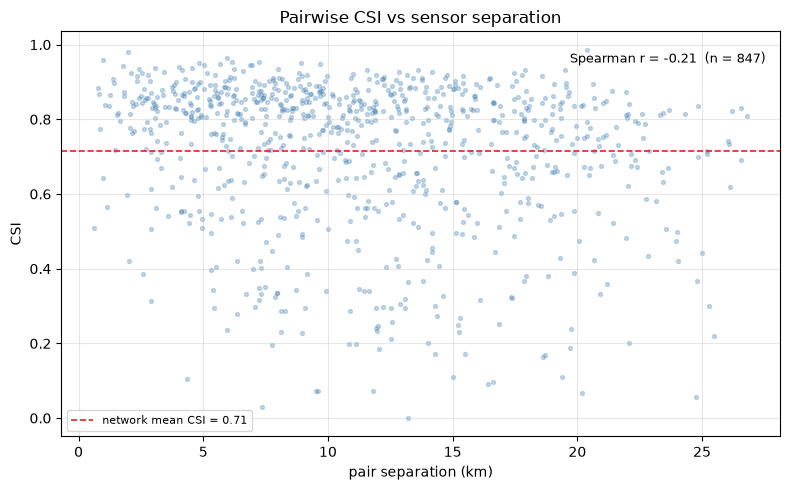

In [9]:
codes = [short_code(c) for c in csi.columns]
pairs = []
for i in range(len(codes)):
    for j in range(i + 1, len(codes)):
        ci, cj = codes[i], codes[j]
        if ci in coords.index and cj in coords.index:
            v = csi.iloc[i, j]
            if pd.notna(v):
                d = haversine_km(coords.loc[ci, "lat"], coords.loc[ci, "lon"],
                                 coords.loc[cj, "lat"], coords.loc[cj, "lon"])
                pairs.append({"a": ci, "b": cj, "km": d, "csi": v})

pairs = pd.DataFrame(pairs)
pairs.to_csv(Tables / "csi_vs_distance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pairs["km"], pairs["csi"], s=8, alpha=0.3, color="steelblue")

# Network mean as a reference — if CSI does not drop with distance,
# low-CSI sensors cannot attribute their score to being "far away"
net_mean = pairs["csi"].mean()
ax.axhline(net_mean, color="tab:red", ls="--", lw=1.2,
           label=f"network mean CSI = {net_mean:.2f}")

r = pairs[["km", "csi"]].corr(method="spearman").iloc[0, 1]
ax.text(0.98, 0.95, f"Spearman r = {r:.2f}  (n = {len(pairs)})",
        ha="right", va="top", transform=ax.transAxes, fontsize=9)
ax.set_xlabel("pair separation (km)")
ax.set_ylabel("CSI")
ax.set_title("Pairwise CSI vs sensor separation")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(Figures / "05_csi_vs_distance.png", dpi=150)
plt.show()

### Recent-window CSI — who is faulty *now*?

The matrix above scores each sensor over its whole lifetime, which answers "who has been unreliable overall" but can hide a sensor that worked well for years and broke recently (the fault is diluted by the healthy years). Recomputing the CSI on only the most recent 12 months answers the operational question instead: **which currently active sensors need a site visit?**

Dead sensors drop out automatically (no valid days in the window), so this is also, in effect, the currently-working-sensors matrix. The window is anchored to the last date in the daily matrix rather than to today, so the result is reproducible once the dataset is frozen. Pairs still need `MIN_COMMON_DAYS` overlapping days; with the thinner 2025–26 network, expect fewer valid pairs per sensor — the `n_pairs` column says how much evidence sits behind each score.

In [10]:
WINDOW_DAYS = RECENT_WINDOW_DAYS
MIN_WINDOW_DAYS_PER_SENSOR = RECENT_MIN_DAYS

end   = daily_matrix.index.max()
start = end - pd.Timedelta(days=WINDOW_DAYS)
recent = daily_matrix.loc[daily_matrix.index > start]

valid_days_recent = recent.notna().sum()
active = valid_days_recent[valid_days_recent >= MIN_WINDOW_DAYS_PER_SENSOR].index
recent = recent[active]

print(f"window: {start.date()} -> {end.date()}")
print(f"sensors active in window (>= {MIN_WINDOW_DAYS_PER_SENSOR} valid days): "
      f"{len(active)} of {daily_matrix.shape[1]}")

csi_recent, ncommon_recent = csi_matrix(recent)
rank_recent = sensor_ranking(csi_recent, ncommon_recent)
rank_recent.index = [short_code(s) for s in rank_recent.index]
print(f"pairs with a valid recent CSI: {int(rank_recent['n_pairs'].sum() / 2)}")
rank_recent.head(10)


window: 2025-08-10 -> 2026-08-10
sensors active in window (>= 60 valid days): 23 of 43
pairs with a valid recent CSI: 242


,mean_csi,n_pairs,median_overlap_days
SL006,0.204,19,106.0
SL008,0.233,19,112.0
SL050,0.251,22,208.0
SL024,0.288,22,209.0
SL022,0.291,22,164.0
SL005,0.517,21,122.0
SL019,0.567,19,78.0
SL040,0.572,22,96.0
SL018,0.592,22,112.0
SL044,0.599,17,54.0


### Lifetime vs recent — comparing like with like

The obvious way to read the two rankings is to subtract one from the other and
call a fall a deterioration. That does not work, and the reason matters.

The CSI is a *relative* measure: a sensor's score depends on which other
sensors it is being compared against and on the concentrations prevailing over
the window. The recent window contains roughly half as many sensors as the
lifetime matrix and covers one particular year, so a change in a sensor's score
mixes together what the sensor did and what the comparison changed. The
symptom is easy to spot — if almost every sensor appears to decline at once,
the window moved, not the network.

The fix is to measure each sensor against the network's own shift over the same
two windows. `change` is the raw difference; `change_vs_network` subtracts the
median change across all sensors judged in both windows, and is the quantity
that says whether a sensor moved *relative to its peers*. Only the second one
supports the word "deteriorating".

In [11]:
cmp = (rank[["mean_csi"]].rename(columns={"mean_csi": "lifetime_csi"})
       .join(rank_recent[["mean_csi", "n_pairs"]]
             .rename(columns={"mean_csi": "recent_csi", "n_pairs": "recent_pairs"}),
             how="left"))
cmp["change"] = cmp["recent_csi"] - cmp["lifetime_csi"]

# The network-wide shift between the two windows, which is what has to be
# removed before a per-sensor change means anything.
network_shift = cmp["change"].median()
cmp["change_vs_network"] = (cmp["change"] - network_shift).round(3)
cmp["change"] = cmp["change"].round(3)

active_cmp = cmp.dropna(subset=["recent_csi"]).sort_values("change_vs_network")
inactive   = cmp[cmp["recent_csi"].isna()].index

n_down = int((active_cmp["change"] < 0).sum())
print(f"sensors judged in both windows: {len(active_cmp)}")
print(f"of these, {n_down} score lower in the recent window and "
      f"{len(active_cmp) - n_down} score higher")
print(f"network median change: {network_shift:+.3f} CSI  "
      f"-- removed as a common shift before ranking\n")

print(f"inactive in the last {WINDOW_DAYS} days ({len(inactive)}): "
      + ", ".join(short_code(s) for s in inactive))
print("\nActive sensors, largest fall relative to the network first:")
active_cmp.round(3)

sensors judged in both windows: 23
of these, 21 score lower in the recent window and 2 score higher
network median change: -0.131 CSI  -- removed as a common shift before ranking

inactive in the last 365 days (20): SL028, SL003, SL015, SL045, SL033, SL035, SL041, SL021, SL017, SL001, SL038, SL023, SL029, SL054, SL055, SL032, SL009, SL036, SL068, SL037

Active sensors, largest fall relative to the network first:


,lifetime_csi,recent_csi,recent_pairs,change,change_vs_network
sensor,,,,,
SL008,0.682,0.233,19.0,-0.449,-0.318
SL024,0.728,0.288,22.0,-0.440,-0.309
SL022,0.582,0.291,22.0,-0.291,-0.160
SL005,0.786,0.517,21.0,-0.269,-0.138
SL006,0.460,0.204,19.0,-0.256,-0.125
SL040,0.778,0.572,22.0,-0.206,-0.075
SL020,0.787,0.614,22.0,-0.173,-0.042
SL011,0.768,0.601,22.0,-0.167,-0.036
SL016,0.749,0.602,22.0,-0.147,-0.016


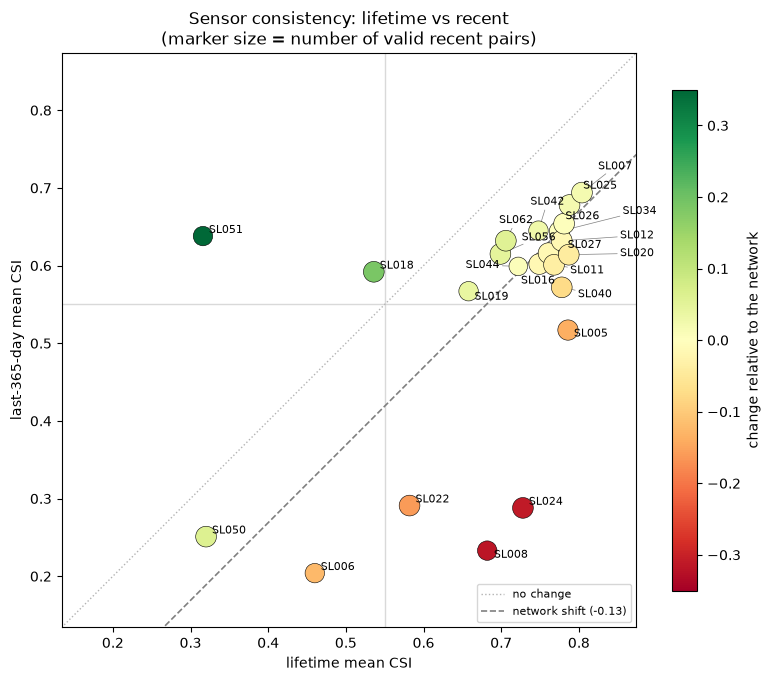

saved figure + table


In [12]:
m = cmp.dropna(subset=["recent_csi"]).copy()

lo = max(0.0, min(m["lifetime_csi"].min(), m["recent_csi"].min()) - 0.07)
hi = min(1.0, max(m["lifetime_csi"].max(), m["recent_csi"].max()) + 0.07)
FAULT = CSI_FLAG_LEVEL   # below this = fault territory (healthy band sits at 0.7-0.85)

fig, ax = plt.subplots(figsize=(8, 7))

# Quadrant guides. The reference line is the network shift, not equality:
# a sensor sitting on it moved exactly as much as the rest of the network.
ax.axhline(FAULT, color="0.85", lw=1, zorder=1)
ax.axvline(FAULT, color="0.85", lw=1, zorder=1)
ax.plot([lo, hi], [lo, hi], ":", color="0.7", lw=1, zorder=2,
        label="no change")
ax.plot([lo, hi], [lo + network_shift, hi + network_shift], "--",
        color="grey", lw=1.2, zorder=2,
        label=f"network shift ({network_shift:+.2f})")

# colour = movement relative to the network, size = evidence (valid recent pairs)
norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.35, vmax=0.35)
sc = ax.scatter(m["lifetime_csi"], m["recent_csi"],
                c=m["change_vs_network"], cmap="RdYlGn", norm=norm,
                s=25 + 9 * m["recent_pairs"], edgecolor="k", lw=0.4, zorder=3)
cb = fig.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label("change relative to the network")

# label every point; adjustText untangles collisions if installed
try:
    from adjustText import adjust_text
    texts = [ax.text(r["lifetime_csi"], r["recent_csi"], short_code(s), fontsize=8)
             for s, r in m.iterrows()]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
except ImportError:   # fallback: alternate offsets around the point
    offsets = [(6, 5), (6, -11), (-34, 5), (-34, -11)]
    for k, (s, r) in enumerate(m.iterrows()):
        dx, dy = offsets[k % 4]
        ax.annotate(short_code(s), (r["lifetime_csi"], r["recent_csi"]),
                    xytext=(dx, dy), textcoords="offset points", fontsize=8)

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("lifetime mean CSI")
ax.set_ylabel(f"last-{WINDOW_DAYS}-day mean CSI")
ax.set_title("Sensor consistency: lifetime vs recent\n"
             "(marker size = number of valid recent pairs)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(Figures / "05_csi_lifetime_vs_recent.png", dpi=200, bbox_inches="tight")
plt.show()

active_cmp.to_csv(Tables / "csi_lifetime_vs_recent.csv")
print("saved figure + table")